In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# 1
sales = pd.read_csv("Sales.csv", sep= "\t")
targets = pd.read_csv("Targets.csv", sep= "\t")
product = pd.read_csv("Product.csv", sep= "\t")
salesperson = pd.read_csv("Salesperson.csv", sep= "\t")
region = pd.read_csv("Region.csv", sep= "\t")

sales["Sales"] = sales["Sales"].str.replace("$", "").str.replace(",", "").astype(float)
sales["Cost"] = sales["Cost"].str.replace("$", "").str.replace(",", "").astype(float)

#display(sales)

sales["Margins"] = sales["Sales"] - sales["Cost"]
#display(sales)

sales["OrderMonth"] = pd.to_datetime(sales["OrderDate"]).dt.month
#display(sales)

#sales.groupby("OrderMonth")["Margins"].agg("mean")
#sales.groupby("OrderMonth")["Margins"].agg("mean").sort_values(ascending=False)

,SalesOrderNumber,OrderDate,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,Quantity,Unit Price,Sales,Cost,Margins,OrderMonth
0,SO43897,"Friday, August 25, 2017",235,312,282,4,2,$28.84,57.68,63.45,-5.77,8
1,SO43897,"Friday, August 25, 2017",351,312,282,4,2,"$2,024.99",4049.98,3796.19,253.79,8
2,SO43897,"Friday, August 25, 2017",348,312,282,4,2,"$2,024.99",4049.98,3796.19,253.79,8
3,SO43897,"Friday, August 25, 2017",232,312,282,4,2,$28.84,57.68,63.45,-5.77,8
4,SO44544,"Saturday, November 18, 2017",292,312,282,4,2,$818.7,1637.40,1413.62,223.78,11
...,...,...,...,...,...,...,...,...,...,...,...,...
57846,SO69476,"Friday, May 15, 2020",476,667,283,2,21,$38.49,808.29,549.70,258.59,5
57847,SO69476,"Friday, May 15, 2020",474,667,283,2,19,$38.49,731.31,497.35,233.96,5
57848,SO69493,"Monday, May 18, 2020",482,89,283,2,20,$4.94,98.80,67.25,31.55,5
57849,SO69503,"Wednesday, May 20, 2020",482,79,282,3,23,$4.94,113.62,77.33,36.29,5


In [32]:
# 2
sales["OrderYear"] = pd.to_datetime(sales["OrderDate"]).dt.year

sales_2020 = sales[sales["OrderYear"] == 2020]
#display(sales_2020)

sales_2020 = sales_2020.merge(salesperson, on="EmployeeKey", how="inner")
#display(sales_2020)

temp = sales_2020.groupby("Salesperson")["Sales"].agg(sum).sort_values(ascending=False).reset_index()
temp[temp.index == 0]

,Salesperson,Sales
0,Linda Mitchell,1612459.84


In [35]:
# 3
sales_2020 = sales[sales["OrderYear"] == 2020]
#display(sales_2020)

sales_2020_merged_with_sales_on_ProductKey = sales_2020.merge(product, on= "ProductKey", how= "inner")
sales_2020_merged_with_sales_on_ProductKey.groupby("Category")["ProductKey"].count()

Category
Accessories     943
Bikes          4419
Clothing       2023
Components     2894
Name: ProductKey, dtype: int64

In [83]:
# 4
#targets["Target"] = targets["Target"].str.replace("$", "").str.replace(",", "").astype(float)
#display(targets)

#targets["TargetYear"] = pd.to_datetime(targets["TargetMonth"]).dt.year
#display(targets)

#revenue_margin = sales.groupby("OrderYear")[["Sales", "Margins"]].sum()
#revenue_margin["Sales + Margins"] = revenue_margin["Sales"] + revenue_margin["Margins"]
#revenue_margin = revenue_margin.reset_index()
#display(revenue_margin)

#target = targets.groupby("TargetYear")["Target"].agg(sum).sort_values(ascending=False).reset_index()
#display(targets)
#display(target)



#revenue_margin.rename(columns={'OrderYear': 'Year'}, inplace=True)
#target.rename(columns={'TargetYear': 'Year'}, inplace=True)

#merged = target.merge(revenue_margin, on="Year", how="inner")
#display(merged)


,Year,Target,Sales,Margins,Sales + Margins
0,2020,192435000.0,12650022.79,29723.29,12679746.08
1,2019,156775000.0,32500005.58,128772.24,32628777.82
2,2018,98700000.0,24328786.25,507753.43,24836539.68
3,2017,35950000.0,8069755.58,333245.61,8403001.19


In [77]:
# 5
product_merged = product.merge(sales, on= "ProductKey", how="inner")
#display(product_merged)

profit = product_merged.groupby(["OrderYear", "Category"])["Margins"].sum().reset_index()
#display(profit)

top_category_per_year = profit.loc[profit.groupby("OrderYear")["Margins"].idxmax()]
display(top_category_per_year)

,OrderYear,Category,Margins
1,2017,Bikes,272851.35
7,2018,Components,426932.32
11,2019,Components,419126.86
15,2020,Components,101141.83


In [88]:
# 6

regions_merged = pd.merge(region, sales, on= "SalesTerritoryKey", how="inner")
#display(regions_merged)

regions_merged = regions_merged.groupby("Region")["Margins"].sum().sort_values(ascending=False).reset_index()
display(regions_merged.iloc[0, 0])

'Northwest'

In [89]:
# 7

regions_merged = regions_merged.groupby("Region")["Margins"].sum().sort_values(ascending=True).reset_index()
display(regions_merged.iloc[0, 0])

'Germany'

In [115]:
# 8

#display(targets)
sales_agg = sales_2020.groupby(["EmployeeKey", "OrderYear"])["Sales"].agg(sum).reset_index()
salesperson_agg = salesperson[["EmployeeID", "EmployeeKey"]]
sales_agg_merged_with_salesperson = salesperson_agg.merge(sales_agg, on= "EmployeeKey", how= "inner")
#display(sales_agg_merged_with_salesperson)


targets_agg = targets.groupby(["EmployeeID","TargetYear"])["Target"].agg(sum).reset_index()
targets_agg = targets_agg[targets_agg["TargetYear"] == 2020]
#display(targets_agg)

targets_agg_merged_with_carnat = targets_agg.merge(sales_agg_merged_with_salesperson, on= "EmployeeID", how= "inner").reset_index()
#display(targets_agg_merged_with_carnat)
targets_agg_merged_with_carnat["Relative to target"] = targets_agg_merged_with_carnat["Sales"] - targets_agg_merged_with_carnat["Target"]
display(targets_agg_merged_with_carnat)

,index,EmployeeID,TargetYear,Target,EmployeeKey,OrderYear,Sales,Relative to target
0,0,61161660,2020,13400000.0,286,2020,501440.25,-12898559.75
1,1,90836195,2020,5100000.0,293,2020,694397.12,-4405602.88
2,2,134219713,2020,3750000.0,292,2020,1259046.21,-2490953.79
3,3,139397894,2020,17900000.0,287,2020,857091.69,-17042908.31
4,4,191644724,2020,10150000.0,282,2020,1612459.84,-8537540.16
5,5,234474252,2020,5600000.0,284,2020,425507.71,-5174492.29
6,6,399771412,2020,5250000.0,288,2020,811065.98,-4438934.02
7,7,481044938,2020,2025000.0,294,2020,22383.10,-2002616.90
8,8,502097814,2020,27750000.0,272,2020,212349.00,-27537651.00
9,9,615389812,2020,2900000.0,283,2020,1036479.79,-1863520.21


In [121]:
# 9
product_merged = product.merge(sales, on= "ProductKey", how="inner")
#display(product_merged)

profit = product_merged.groupby(["OrderYear", "Category"])["Sales"].agg(sum).reset_index()
display(profit)

,OrderYear,Category,Sales
0,2017,Accessories,20243.09
1,2017,Bikes,7399568.63
2,2017,Clothing,34469.13
3,2017,Components,615474.73
4,2018,Accessories,93801.75
5,2018,Bikes,20134150.28
6,2018,Clothing,489790.65
7,2018,Components,3611043.57
8,2019,Accessories,301267.77
9,2019,Bikes,25827772.63


In [134]:
# 10

product_merged = product.merge(sales, on= "ProductKey", how="inner")
product_merged["Average"] = product_merged.groupby("Category")["Sales"].transform("mean")

product_merged["Average - Sales"] = product_merged["Average"] - product_merged["Sales"]

display(product_merged)


,ProductKey,Product,Standard Cost,Color,Subcategory,Category,Background Color Format,Font Color Format,SalesOrderNumber,OrderDate,...,SalesTerritoryKey,Quantity,Unit Price,Sales,Cost,Margins,OrderMonth,OrderYear,Average,Average - Sales
0,215,"Sport-100 Helmet, Black",$12.03,Black,Helmets,Accessories,#000000,#FFFFFF,SO44776,"Saturday, December 23, 2017",...,4,2,$20.19,40.38,24.06,16.32,12,2017,111.708680,71.328680
1,215,"Sport-100 Helmet, Black",$12.03,Black,Helmets,Accessories,#000000,#FFFFFF,SO44521,"Monday, November 13, 2017",...,4,2,$20.19,40.38,24.06,16.32,11,2017,111.708680,71.328680
2,215,"Sport-100 Helmet, Black",$12.03,Black,Helmets,Accessories,#000000,#FFFFFF,SO46058,"Tuesday, May 15, 2018",...,4,2,$20.19,40.38,24.06,16.32,5,2018,111.708680,71.328680
3,215,"Sport-100 Helmet, Black",$12.03,Black,Helmets,Accessories,#000000,#FFFFFF,SO43680,"Tuesday, July 18, 2017",...,4,2,$20.19,40.38,24.06,16.32,7,2017,111.708680,71.328680
4,215,"Sport-100 Helmet, Black",$12.03,Black,Helmets,Accessories,#000000,#FFFFFF,SO44783,"Sunday, December 24, 2017",...,4,2,$20.19,40.38,24.06,16.32,12,2017,111.708680,71.328680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57846,603,HL Bottom Bracket,$53.94,NaN,Bottom Brackets,Components,#DCDCDC,#000000,SO53459,"Monday, September 2, 2019",...,4,6,$72.89,437.34,323.65,113.69,9,2019,637.174352,199.834352
57847,603,HL Bottom Bracket,$53.94,NaN,Bottom Brackets,Components,#DCDCDC,#000000,SO55297,"Tuesday, October 22, 2019",...,6,7,$72.89,510.23,377.59,132.64,10,2019,637.174352,126.944352
57848,603,HL Bottom Bracket,$53.94,NaN,Bottom Brackets,Components,#DCDCDC,#000000,SO51857,"Thursday, August 29, 2019",...,7,7,$72.89,510.23,377.59,132.64,8,2019,637.174352,126.944352
57849,603,HL Bottom Bracket,$53.94,NaN,Bottom Brackets,Components,#DCDCDC,#000000,SO59068,"Sunday, December 29, 2019",...,4,8,$72.89,583.12,431.53,151.59,12,2019,637.174352,54.054352


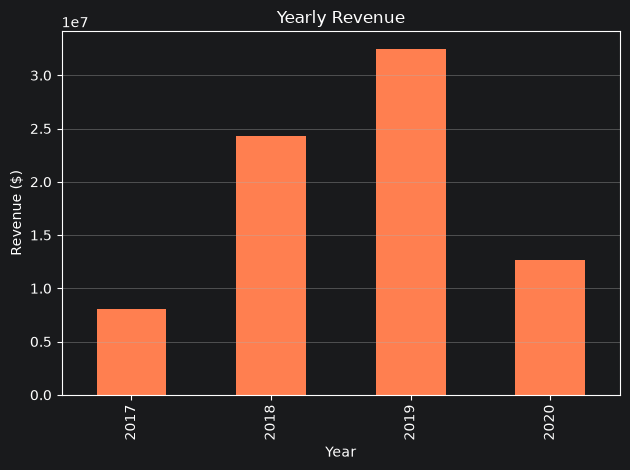

In [136]:
# 11

yearly_revenue = sales.groupby("OrderYear")["Sales"].sum().reset_index()


yearly_revenue.plot(kind='bar',
                    x='OrderYear',
                    y='Sales',
                    color='coral',
                    title='Yearly Revenue',
                    legend=False)


plt.xlabel('Year')
plt.ylabel('Revenue ($)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()